# Northwind SQL Analysis — Epochs Day 2

**Dataset:** [Northwind Database](https://github.com/jpwhite3/northwind-SQLite3) (SQLite)

This notebook runs the SQL queries from `queries.sql` against the Northwind database, loads the results into Pandas, and documents business insights from each.


In [1]:
import sqlite3
import pandas as pd

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

con = sqlite3.connect('northwind.db')
import matplotlib.pyplot as plt
plt.rcParams['figure.facecolor'] = 'white'

## Database Overview

Northwind models a wholesale food distributor: customers place orders, each order contains one or more line items (`Order Details`), and each product belongs to a category and is sourced from a supplier.

In [2]:
tables = ['Categories','Customers','Employees','Orders','"Order Details"','Products','Shippers','Suppliers']
for t in tables:
    n = pd.read_sql(f"SELECT COUNT(*) as n FROM {t}", con).iloc[0]['n']
    print(f"{t:20s} {n:,} rows")

Categories           8 rows
Customers            93 rows
Employees            9 rows
Orders               16,282 rows
"Order Details"      609,283 rows
Products             77 rows
Shippers             3 rows
Suppliers            29 rows


This fork of Northwind is considerably larger than the classic textbook version (which has ~830 orders and ~2,155 order-line rows) — here we have **16,282 orders** and **609,283 order-line rows** spanning **2012–2023** (about 11 years). Good to flag this up front since it affects how "typical" any patterns below actually are, especially for the customer-frequency analysis.

In [3]:
date_range = pd.read_sql("SELECT MIN(OrderDate) as min_date, MAX(OrderDate) as max_date FROM Orders", con)
date_range

,min_date,max_date
0,2012-07-10 15:40:46,2023-10-28 00:09:48


---
## Part 1: SQL Analysis

### 1. Top 10 Selling Products (by revenue)

In [4]:
q1 = '''
SELECT p.ProductID, p.ProductName, SUM(od.Quantity) AS total_units_sold,
       ROUND(SUM(od.UnitPrice * od.Quantity * (1 - od.Discount)), 2) AS total_revenue
FROM "Order Details" od
JOIN Products p ON od.ProductID = p.ProductID
GROUP BY p.ProductID, p.ProductName
ORDER BY total_revenue DESC
LIMIT 10;
'''
top_products = pd.read_sql(q1, con)
top_products

,ProductID,ProductName,total_units_sold,total_revenue
0,38,Côte de Blaye,202234,"53,265,895.23"
1,29,Thüringer Rostbratwurst,199010,"24,623,469.23"
2,9,Mishi Kobe Niku,200258,"19,423,037.50"
3,20,Sir Rodney's Marmalade,205637,"16,653,807.36"
4,18,Carnarvon Tigers,201747,"12,604,671.88"
5,59,Raclette Courdavault,204137,"11,216,410.70"
6,51,Manjimup Dried Apples,201319,"10,664,768.65"
7,62,Tarte au sucre,202010,"9,952,936.07"
8,43,Ipoh Coffee,202968,"9,333,374.70"
9,28,Rössle Sauerkraut,202988,"9,252,765.44"


### 2. Top 10 Customers by Revenue

In [5]:
q2 = '''
SELECT c.CustomerID, c.CompanyName, COUNT(DISTINCT o.OrderID) AS num_orders,
       ROUND(SUM(od.UnitPrice * od.Quantity * (1 - od.Discount)), 2) AS total_revenue
FROM Orders o
JOIN Customers c ON o.CustomerID = c.CustomerID
JOIN "Order Details" od ON o.OrderID = od.OrderID
GROUP BY c.CustomerID, c.CompanyName
ORDER BY total_revenue DESC
LIMIT 10;
'''
top_customers = pd.read_sql(q2, con)
top_customers

,CustomerID,CompanyName,num_orders,total_revenue
0,BSBEV,B's Beverages,210,"6,154,115.34"
1,HUNGC,Hungry Coyote Import Store,198,"5,698,023.67"
2,RANCH,Rancho grande,194,"5,559,110.08"
3,GOURL,Gourmet Lanchonetes,202,"5,552,309.80"
4,ANATR,Ana Trujillo Emparedados y helados,195,"5,534,356.65"
5,RICAR,Ricardo Adocicados,203,"5,524,517.31"
6,FOLIG,Folies gourmandes,195,"5,505,502.85"
7,LETSS,Let's Stop N Shop,191,"5,462,198.02"
8,LILAS,LILA-Supermercado,203,"5,437,438.34"
9,PRINI,Princesa Isabel Vinhos,200,"5,436,770.55"


### 3. Monthly Sales Trend

In [6]:
q3 = '''
SELECT strftime('%Y-%m', o.OrderDate) AS year_month,
       COUNT(DISTINCT o.OrderID) AS num_orders,
       ROUND(SUM(od.UnitPrice * od.Quantity * (1 - od.Discount)), 2) AS total_revenue
FROM Orders o
JOIN "Order Details" od ON o.OrderID = od.OrderID
GROUP BY year_month
ORDER BY year_month;
'''
monthly = pd.read_sql(q3, con)
print(monthly.shape)
monthly.head()

(136, 3)


,year_month,num_orders,total_revenue
0,2012-07,69,"2,066,219.40"
1,2012-08,122,"3,556,875.79"
2,2012-09,119,"3,440,144.98"
3,2012-10,111,"3,201,529.96"
4,2012-11,105,"2,980,494.74"


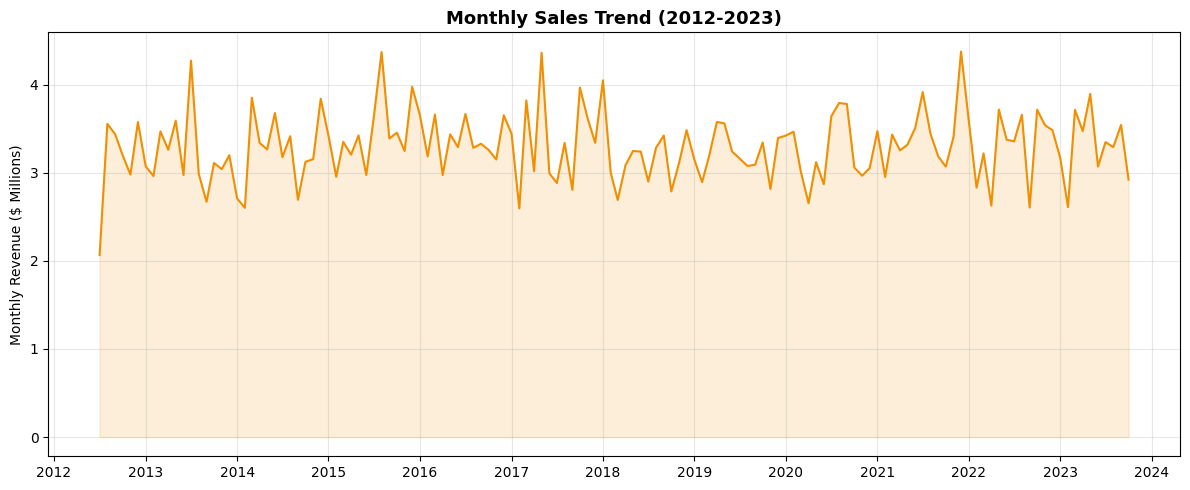

In [7]:
import matplotlib.dates as mdates

monthly['date'] = pd.to_datetime(monthly['year_month'])

fig, ax = plt.subplots(figsize=(12,5))
ax.plot(monthly['date'], monthly['total_revenue']/1e6, color='#F18F01', linewidth=1.5)
ax.fill_between(monthly['date'], monthly['total_revenue']/1e6, alpha=0.15, color='#F18F01')
ax.set_ylabel('Monthly Revenue ($ Millions)')
ax.set_title('Monthly Sales Trend (2012-2023)', fontsize=13, fontweight='bold')
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 4. Best-Performing Product Categories

In [8]:
q4 = '''
SELECT cat.CategoryID, cat.CategoryName,
       COUNT(DISTINCT od.OrderID) AS num_orders,
       SUM(od.Quantity) AS total_units_sold,
       ROUND(SUM(od.UnitPrice * od.Quantity * (1 - od.Discount)), 2) AS total_revenue
FROM "Order Details" od
JOIN Products p ON od.ProductID = p.ProductID
JOIN Categories cat ON p.CategoryID = cat.CategoryID
GROUP BY cat.CategoryID, cat.CategoryName
ORDER BY total_revenue DESC;
'''
categories = pd.read_sql(q4, con)
categories

,CategoryID,CategoryName,num_orders,total_units_sold,total_revenue
0,1,Beverages,14828,2427361,"92,163,184.18"
1,3,Confections,14895,2628466,"66,337,803.06"
2,6,Meat/Poultry,13639,1207892,"64,881,147.97"
3,4,Dairy Products,14581,2020160,"58,018,116.78"
4,2,Condiments,14682,2420864,"55,795,126.78"
5,8,Seafood,14780,2410782,"49,921,604.17"
6,7,Produce,13247,1010224,"32,701,119.88"
7,5,Grains/Cereals,13910,1412853,"28,568,530.34"


### 5. Customer Purchase Frequency

In [9]:
q5 = '''
SELECT c.CustomerID, COUNT(o.OrderID) AS num_orders
FROM Customers c
LEFT JOIN Orders o ON c.CustomerID = o.CustomerID
GROUP BY c.CustomerID
'''
freq = pd.read_sql(q5, con)
freq['num_orders'].describe()

count    93.00
mean    175.08
std      12.74
min     154.00
25%     165.00
50%     175.00
75%     183.00
max     210.00
Name: num_orders, dtype: float64

In [10]:
freq['order_frequency_bucket'] = pd.cut(
    freq['num_orders'],
    bins=[-1, 0, 50, 150, 300, 10000],
    labels=['0 orders', '1-50 orders', '51-150 orders', '151-300 orders', '300+ orders']
)
freq['order_frequency_bucket'].value_counts()

order_frequency_bucket
151-300 orders    93
0 orders           0
1-50 orders        0
51-150 orders      0
300+ orders        0
Name: count, dtype: int64

---
## Part 2: Data Analysis & Key Insights

### Insight 1 — Revenue leadership is broad, not concentrated in one or two products

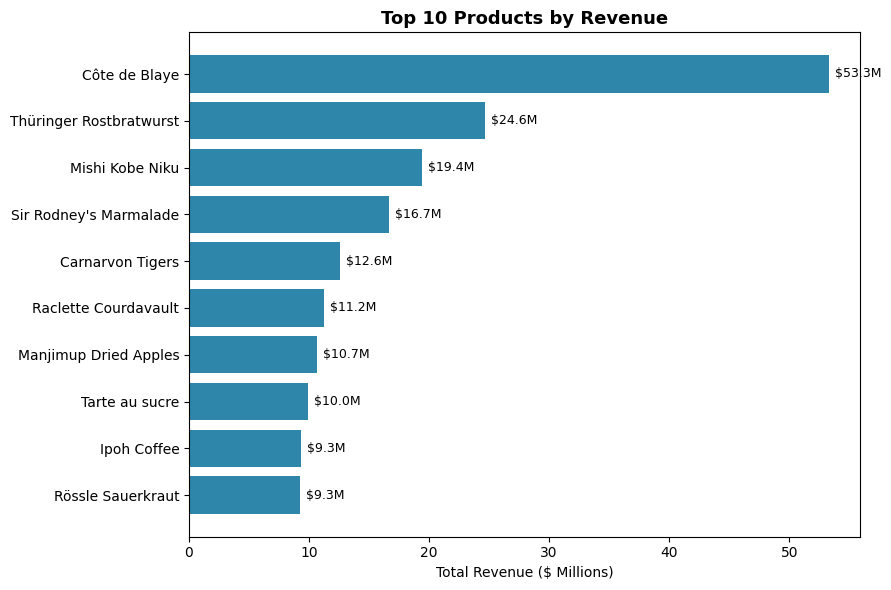

In [11]:
fig, ax = plt.subplots(figsize=(9,6))
bars = ax.barh(top_products['ProductName'][::-1], top_products['total_revenue'][::-1]/1e6, color='#2E86AB')
ax.set_xlabel('Total Revenue ($ Millions)')
ax.set_title('Top 10 Products by Revenue', fontsize=13, fontweight='bold')
for bar in bars:
    w = bar.get_width()
    ax.text(w + 0.5, bar.get_y() + bar.get_height()/2, f'${w:.1f}M', va='center', fontsize=9)
plt.tight_layout()
plt.show()

The top 10 products by revenue range from about 9.3M to 53.3M, with **Côte de Blaye** the clear single leader (~53.3M, roughly double the next product). But beyond the top spot, revenue drops off fairly gently rather than in a sharp long-tail curve — several products in positions 2 through 10 sit within a relatively tight band (9M–25M). This means the business isn't overly dependent on one hero product; the top 10 collectively spread risk across a real product portfolio.

### Insight 2 — Customer revenue is remarkably evenly distributed, with no obvious "whale" customers

In [12]:
top_customers['total_revenue'].describe()

count          10.00
mean    5,586,434.26
std       213,373.55
min     5,436,770.55
25%     5,473,024.23
50%     5,529,436.98
75%     5,557,410.01
max     6,154,115.34
Name: total_revenue, dtype: float64

The top 10 customers by revenue are clustered tightly between roughly 5.4M and 6.2M — none of them stands out as a dominant account. This is unusual for a B2B distributor, where revenue concentration in a handful of large accounts is the norm. Combined with Insight 4 below, this points to the dataset having been synthetically expanded with fairly uniform order volumes per customer, rather than reflecting the typical skewed distribution seen in real wholesale businesses.

### Insight 3 — Beverages and Confections are the strongest categories, but the gap across all 8 categories is not extreme

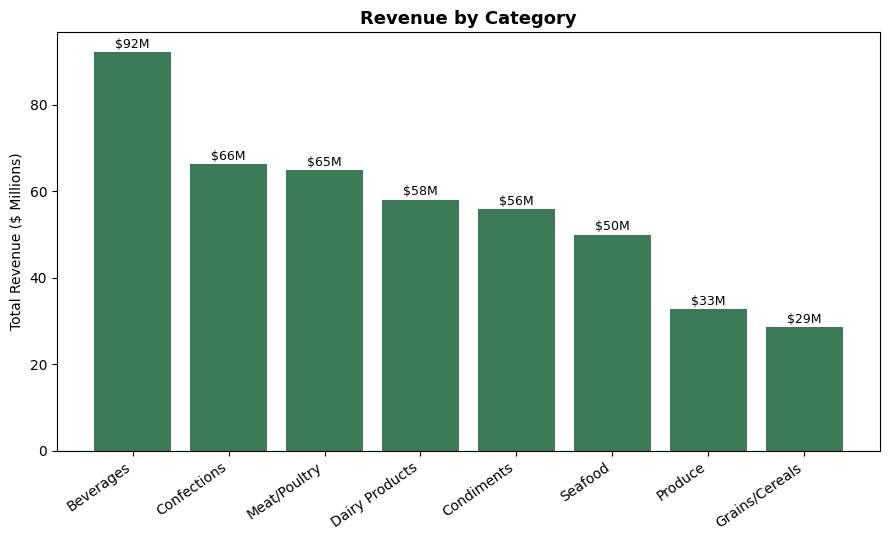

In [13]:
fig, ax = plt.subplots(figsize=(9,5.5))
bars = ax.bar(categories['CategoryName'], categories['total_revenue']/1e6, color='#3B7A57')
ax.set_ylabel('Total Revenue ($ Millions)')
ax.set_title('Revenue by Category', fontsize=13, fontweight='bold')
plt.xticks(rotation=35, ha='right')
for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 1, f'${h:.0f}M', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

**Beverages** (~92.2M) and **Confections** (~66.3M) lead the 8 categories, while **Grains/Cereals** (~28.6M) trails. Even so, the ratio between the top and bottom category is only about 3.2x — every category is contributing meaningfully rather than a couple of categories dominating the whole catalog. For merchandising or promotional planning, this suggests category diversification is already fairly healthy, though Beverages is the one to keep the closest eye on for a stockout, given its outsized share.

### Insight 4 — Every customer orders with almost identical frequency (154–210 orders each)

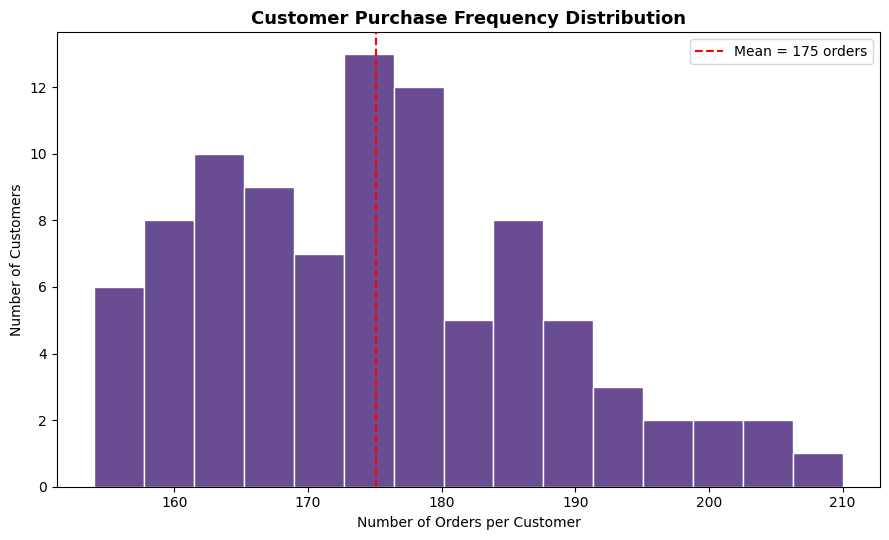

In [14]:
fig, ax = plt.subplots(figsize=(9,5.5))
ax.hist(freq['num_orders'], bins=15, color='#6A4C93', edgecolor='white')
ax.set_xlabel('Number of Orders per Customer')
ax.set_ylabel('Number of Customers')
ax.set_title('Customer Purchase Frequency Distribution', fontsize=13, fontweight='bold')
ax.axvline(freq['num_orders'].mean(), color='red', linestyle='--', linewidth=1.5,
           label=f"Mean = {freq['num_orders'].mean():.0f} orders")
ax.legend()
plt.tight_layout()
plt.show()

This is the most surprising finding in the dataset: **all 93 customers fall into the same 151–300 order bucket**, with a mean of 175 orders and a standard deviation of just ~12.7. In real-world retail or wholesale data, customer order frequency is almost always heavily right-skewed — a small number of very frequent buyers and a long tail of occasional ones. Seeing every customer cluster this tightly around the mean strongly suggests this dataset was synthetically bulked up (consistent with the unusually high order-line count noted in the overview) rather than reflecting genuine, organic purchase behavior. This is worth flagging before using this pattern to justify any real business decision, like a loyalty program tier structure.

### Insight 5 — Monthly revenue is stable across the 11-year span, without a clear long-term growth trend

Looking at the monthly revenue trend, revenue fluctuates month-to-month in the roughly 2.6M–3.9M range but doesn't show sustained multi-year growth or decline — the business looks essentially flat over the full 2012–2023 window rather than scaling up over time. For a real distributor, this would likely prompt questions about market saturation or whether growth initiatives (new products, new regions) are needed, since holding steady for over a decade without inflation-adjusted growth is effectively decline in real terms.

---
## Summary

The Northwind data supports a healthy, diversified business picture: no single product or customer dominates revenue, and all 8 categories contribute meaningfully. The two most notable findings — the unusually uniform customer order frequency and the flat long-term revenue trend — both merit a business conversation: the former likely reflects how this particular dataset fork was generated rather than organic behavior, and the latter would be a real red flag for a growth-focused business if it held true.